In [1]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import scipy.sparse as sp
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
})
plt.style.use('tableau-colorblind10')
# Set the global font size
plt.rcParams['font.size'] = 16

In [3]:
def finite_difference_known(f, a, b, N):
    """Approximate f'(x) using the requested finite differences."""
    if N < 3:
        raise ValueError("N must be at least 3.")

    grid = np.linspace(a, b, N)
    dx = grid[1] - grid[0]
    values = f(grid)
    derivative = np.empty(N)

    # First-order one-sided differences at x=a and x=b.
    derivative[0] = (values[1] - values[0]) / dx
    derivative[-1] = (values[-1] - values[-2]) / dx

    # Second-order centered differences at interior points.
    derivative[1:-1] = (values[2:] - values[:-2]) / (2 * dx)

    return grid, derivative

def relative_error(approx, exact, norm):
    """Compute the relative error between an approximate and exact value."""
    return np.linalg.norm(approx - exact, norm) / np.linalg.norm(exact, norm)


# Problem 1

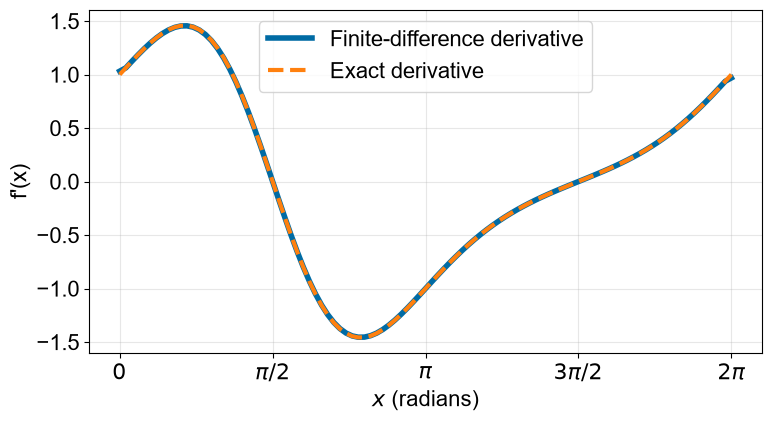

In [4]:
f = lambda x: np.exp(np.sin(x))
exact_derivative = lambda x: np.exp(np.sin(x)) * np.cos(x)

N = 101
x, numerical_derivative = finite_difference_known(f, 0, 2 * np.pi, N)

plt.figure(figsize=(8, 4.5))
plt.plot(x, numerical_derivative, label="Finite-difference derivative", linewidth=4)
plt.plot(x, exact_derivative(x), "--", label="Exact derivative", linewidth=3)
plt.xlabel(r"$x$ (radians)")
plt.xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
           [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
plt.ylabel("f'(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


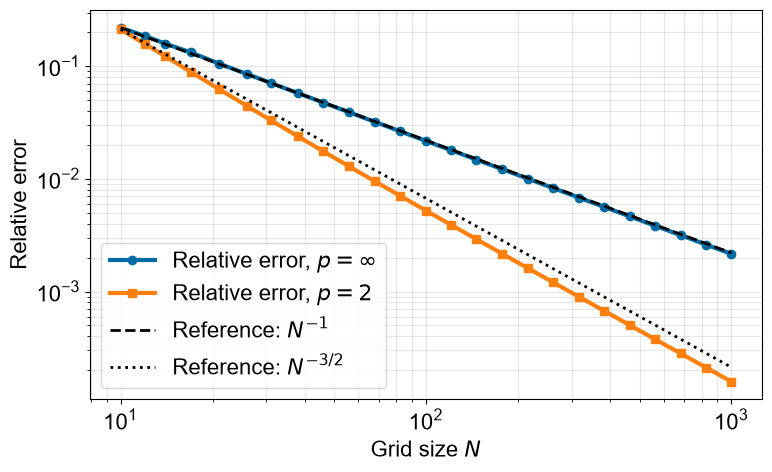

In [5]:
# Compute relative errors on increasingly fine grids.
N_values = np.unique(np.logspace(1, 3, 25, dtype=int))
error_inf = np.empty(len(N_values))
error_2 = np.empty(len(N_values))

for index, N in enumerate(N_values):
    x, numerical_derivative = finite_difference_known(f, 0, 2 * np.pi, N)
    exact_values = exact_derivative(x)
    error_inf[index] = relative_error(numerical_derivative, exact_values, np.inf)
    error_2[index] = relative_error(numerical_derivative, exact_values, 2)

# Reference curves, scaled to the first measured errors.
reference_inf = error_inf[0] * (N_values / N_values[0]) ** (-1)
reference_2 = error_2[0] * (N_values / N_values[0]) ** (-1.5)

plt.figure(figsize=(8, 5))
plt.loglog(N_values, error_inf, "o-", label=r"Relative error, $p=\infty$", linewidth=3)
plt.loglog(N_values, error_2, "s-", label=r"Relative error, $p=2$", linewidth=3)
plt.loglog(N_values, reference_inf, "k--", label=r"Reference: $N^{-1}$", linewidth=2)
plt.loglog(N_values, reference_2, "k:", label=r"Reference: $N^{-3/2}$", linewidth=2)
plt.xlabel(r"Grid size $N$")
plt.ylabel("Relative error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Problem 2

In [6]:
def finite_difference_d2(f, a, b, N):
    """Approximate f''(x) using the requested finite differences."""
    if N < 3:
        raise ValueError("N must be at least 3.")

    grid = np.linspace(a, b, N)
    dx = grid[1] - grid[0]
    values = f(grid)
    derivative = np.empty(N)

    # Second-order centered differences for second derivative, periodic boundaries
    derivative = (values[1:] - 2*values[:-1] + np.roll(values[:-1], 1)) / (dx**2)

    return grid[:-1], derivative

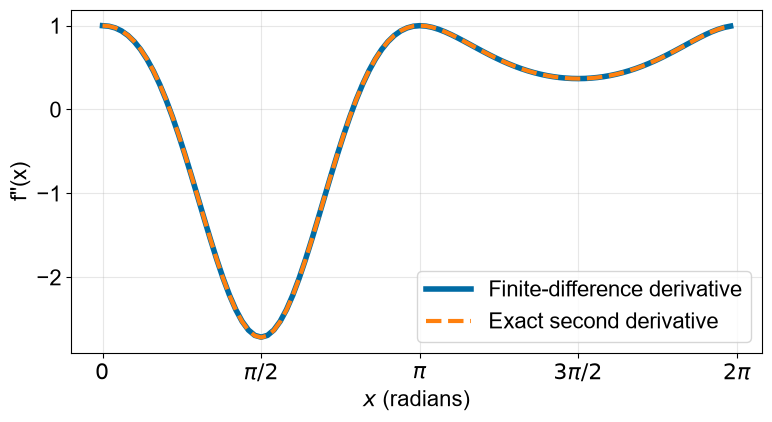

In [7]:
f = lambda x: np.exp(np.sin(x))
exact_d2 = lambda x: np.exp(np.sin(x)) * (np.cos(x)**2) - np.exp(np.sin(x)) * (np.sin(x))

N = 101
x, numerical_derivative = finite_difference_d2(f, 0, 2 * np.pi, N)

plt.figure(figsize=(8, 4.5))
plt.plot(x, numerical_derivative, label="Finite-difference derivative", linewidth=4)
plt.plot(x, exact_d2(x), "--", label="Exact second derivative", linewidth=3)
plt.xlabel(r"$x$ (radians)")
plt.xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
           [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
plt.ylabel("f''(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

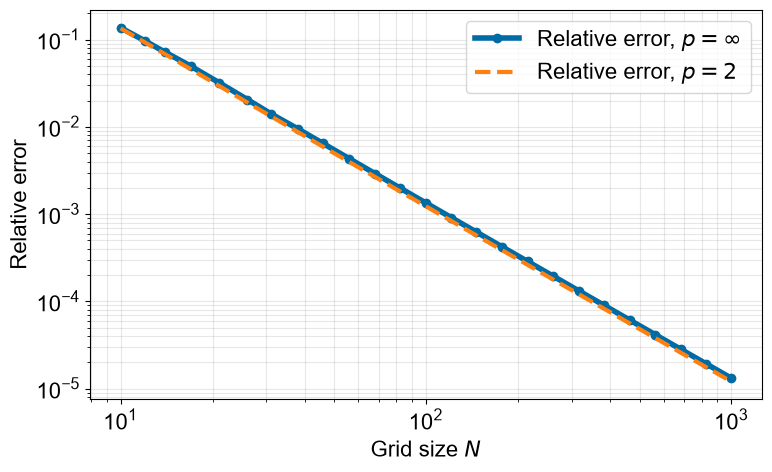

In [8]:
# Compute relative errors on increasingly fine grids.
N_values = np.unique(np.logspace(1, 3, 25, dtype=int))
error_inf = np.empty(len(N_values))
error_2 = np.empty(len(N_values))

for index, N in enumerate(N_values):
    x, numerical_d2 = finite_difference_d2(f, 0, 2 * np.pi, N)
    exact_values = exact_d2(x)
    error_inf[index] = relative_error(numerical_d2, exact_values, np.inf)
    error_2[index] = relative_error(numerical_d2, exact_values, 2)

plt.figure(figsize=(8, 5))
plt.loglog(N_values, error_inf, "o-", label=r"Relative error, $p=\infty$", linewidth=4)
plt.loglog(N_values, error_2, "--", label=r"Relative error, $p=2$", linewidth=3)
plt.xlabel(r"Grid size $N$")
plt.ylabel("Relative error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 3

In [9]:
def manufactured_finite_diff(f, a, b, N, bndry_a, bndry_b):
    """Approximate u(x) using f and the boundaries."""
    if N < 3:
        raise ValueError("N must be at least 3.")

    grid = np.linspace(a, b, N+1)
    dx = grid[1] - grid[0]
    values = f(grid[1:-1])

    row = []
    col = []
    val = []

    row.append(0)
    col.append(0)
    val.append(1)

    row.append(N)
    col.append(N)
    val.append(1)

    for i in range(1, N):
        row.append(i)
        col.append(i-1)
        val.append(1-(dx/2)*np.sin(grid[i]))

        row.append(i)
        col.append(i)
        val.append(-2 + dx**2)

        row.append(i)
        col.append(i+1)
        val.append(1+(dx/2)*np.sin(grid[i]))

    d2 = coo_matrix((val, (row, col)))
    d2 = d2.tocsc()

    b = np.zeros(N+1)
    b[0] = bndry_a
    b[1:N] = dx**2 * values
    b[N] = bndry_b

    solution = spsolve(d2, b)

    return solution, grid

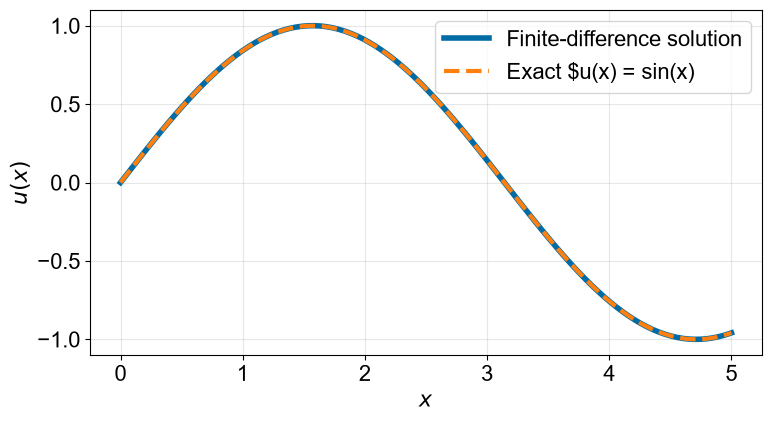

In [10]:
f = lambda x: np.sin(x) * np.cos(x)

a = 0
b = 5
bndry_a = np.sin(a)
bndry_b = np.sin(b)

N = 101
u, x = manufactured_finite_diff(f, a, b, N, bndry_a, bndry_b)

plt.figure(figsize=(8, 4.5))
plt.plot(x, u, label="Finite-difference solution", linewidth=4)
plt.plot(x, np.sin(x), "--", label=r"Exact $u(x) = sin(x)", linewidth=3)
plt.xlabel(r"$x$")
plt.xticks([0, 1, 2, 3, 4, 5])
plt.ylabel(r"$u(x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

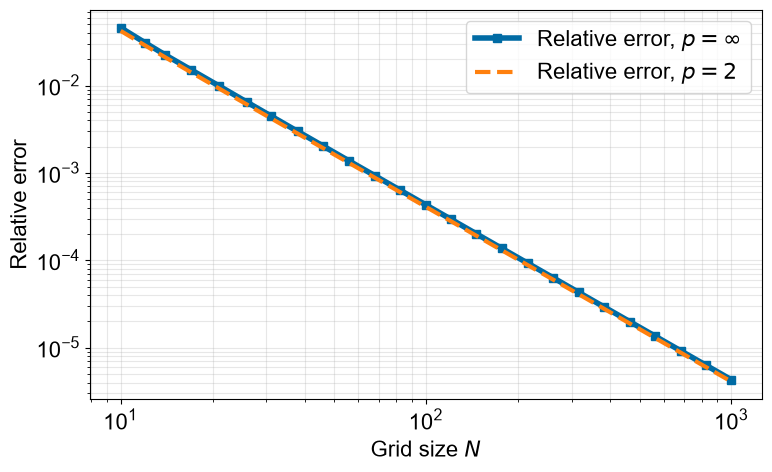

In [11]:
# Compute relative errors on increasingly fine grids.
N_values = np.unique(np.logspace(1, 3, 25, dtype=int))
error_2 = np.empty(len(N_values))
error_inf = np.empty(len(N_values))

for index, N in enumerate(N_values):
    numerical_d2, x = manufactured_finite_diff(f, a, b, N, bndry_a, bndry_b)
    exact_values = np.sin(x)
    error_2[index] = relative_error(numerical_d2, exact_values, 2)
    error_inf[index] = relative_error(numerical_d2, exact_values, np.inf)

plt.figure(figsize=(8, 5))
plt.loglog(N_values, error_inf, "s-", label=r"Relative error, $p=\infty$", linewidth=4)
plt.loglog(N_values, error_2, "--", label=r"Relative error, $p=2$", linewidth=3)
plt.xlabel(r"Grid size $N$")
plt.ylabel("Relative error")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Problem 4

In [12]:
def finite_diff_2d(f, Nx, Ny, x_min, x_max, y_min, y_max, exact):
    """Solve u_xx + u_yy = f with Dirichlet boundary conditions."""
    if Nx < 2 or Ny < 2:
        raise ValueError("Nx and Ny must each be at least 2.")

    dx = (x_max - x_min) / Nx
    dy = (y_max - y_min) / Ny

    x = np.linspace(x_min, x_max, Nx + 1)
    y = np.linspace(y_min, y_max, Ny + 1)
    nx, ny = Nx + 1, Ny + 1

    X, Y = np.meshgrid(x, y)

    Dx = sp.diags([1 , -2 , 1], [ -1 , 0 , 1], shape = (nx, nx)) / dx**2
    Dy = sp.diags([1 , -2 , 1], [ -1 , 0 , 1], shape = (ny, ny)) / dy**2

    # 2D Laplacian : L = I_y (x) Dx + Dy (x) I_x
    Ix = sp.eye(nx)
    Iy = sp.eye(ny)
    L = sp.kron(Iy, Dx) + sp.kron(Dy, Ix)

    F = f(X, Y)
    F = F.flatten()

    # Exact solution / Dirichlet BC
    U_exact = exact(X, Y)
    u_bc = U_exact.flatten()

    # Find boundary points
    boundary = np.zeros((ny, nx), dtype=bool)

    boundary[0, :] = True
    boundary[-1, :] = True
    boundary[:, 0] = True
    boundary[:, -1] = True

    boundary_idx = np.where(boundary.flatten())[0]

    # Enforce Dirichlet BC
    L = L.tolil()

    for k in boundary_idx:
        L.rows[k] = [k]
        L.data[k] = [1.0]
        F[k] = u_bc[k]

    phi = spsolve(L.tocsr(), F)
    Phi = phi.reshape(ny, nx)

    return x, y, Phi

C:\Users\jacks\AppData\Local\Temp\ipykernel_11252\506555120.py:15: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Dx = sp.diags([1 , -2 , 1], [ -1 , 0 , 1], shape = (nx, nx)) / dx**2
C:\Users\jacks\AppData\Local\Temp\ipykernel_11252\506555120.py:16: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Dy = sp.diags([1 , -2 , 1], [ -1 , 0 , 1], shape = (ny, ny)) / dy**2


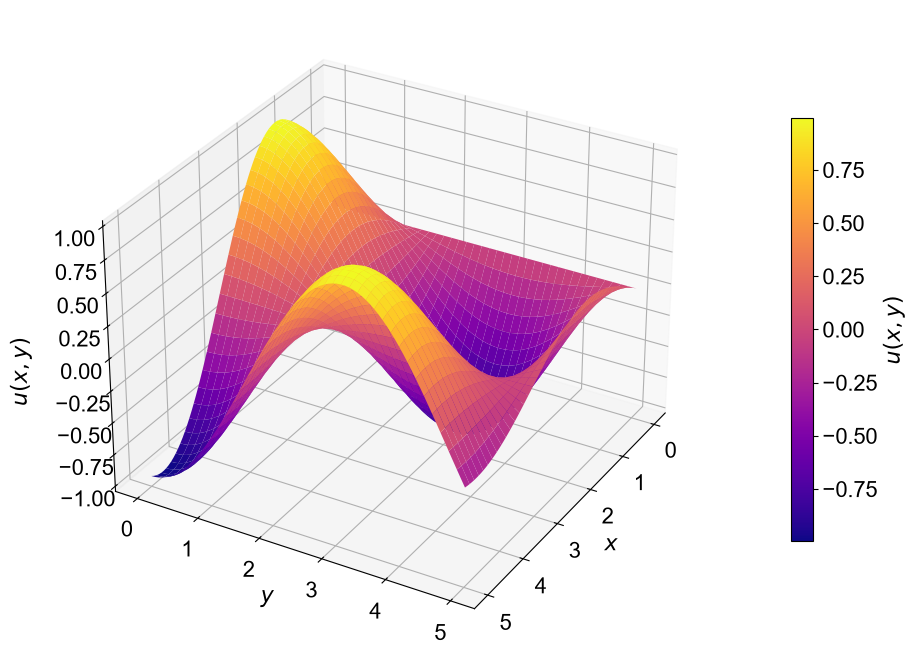

In [13]:
# Manufactured solution and forcing for Problem 4.
u_exact_2d = lambda x, y: np.sin(x) * np.cos(y)
f_2d = lambda x, y: -2 * np.sin(x) * np.cos(y)

a = 0
b = 5
bndry_x_min = lambda y: u_exact_2d(a, y)
bndry_x_max = lambda y: u_exact_2d(b, y)
bndry_y_min = lambda x: u_exact_2d(x, a)
bndry_y_max = lambda x: u_exact_2d(x, b)

N = 80
x, y, u_numerical = finite_diff_2d(
    f_2d, N, N, a, b, a, b, 
    u_exact_2d
)
X, Y = np.meshgrid(x, y, indexing="xy")

# plt.figure(figsize=(8, 6))
# contours = plt.contourf(X, Y, u_numerical, levels=30, cmap="plasma")
# plt.colorbar(contours, label=r"$u_h(x,y)$")
# plt.xlabel(r"$x$")
# plt.ylabel(r"$y$")
# plt.title(r"Finite-difference solution of $\nabla^2 u=f(x,y)$ ($N=80$)")
# plt.tight_layout()
# plt.show()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, u_numerical, cmap="plasma", linewidth=0, antialiased=True)
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label=r"$u(x,y)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r"$u(x,y)$", labelpad=15, rotation=90)
ax.view_init(elev=30, azim=30)

plt.tight_layout()
plt.show()

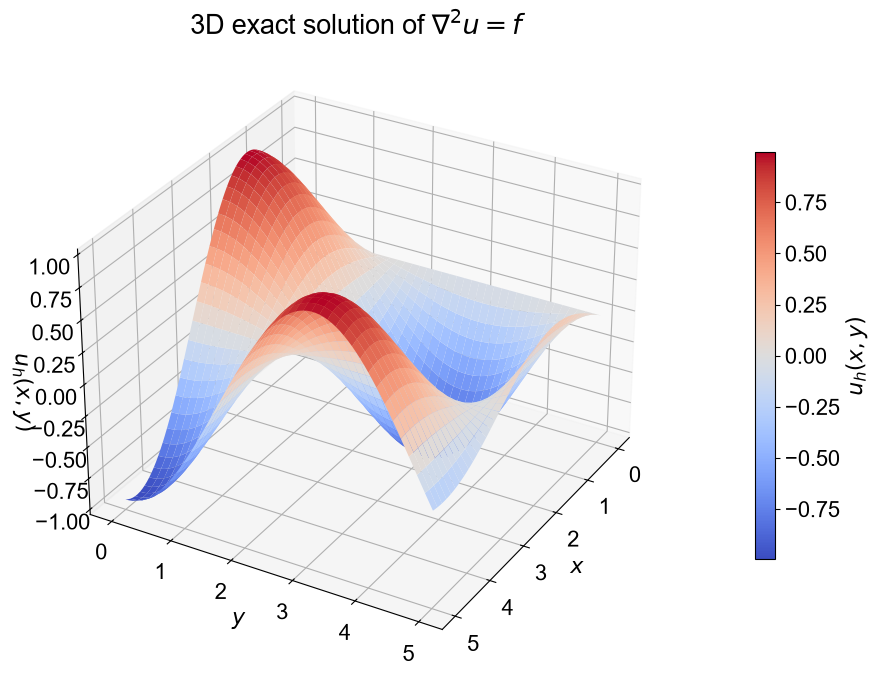

In [14]:
# Verify
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, u_exact_2d(X, Y), cmap="coolwarm", linewidth=0, antialiased=True)
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.1, label=r"$u_h(x,y)$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_zlabel(r"$u_h(x,y)$")
ax.view_init(elev=30, azim=30)

ax.set_title(r"3D exact solution of $\nabla^2 u=f$")
plt.tight_layout()
plt.show()

C:\Users\jacks\AppData\Local\Temp\ipykernel_11252\506555120.py:15: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Dx = sp.diags([1 , -2 , 1], [ -1 , 0 , 1], shape = (nx, nx)) / dx**2
C:\Users\jacks\AppData\Local\Temp\ipykernel_11252\506555120.py:16: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  Dy = sp.diags([1 , -2 , 1], [ -1 , 0 , 1], shape = (ny, ny)) / dy**2


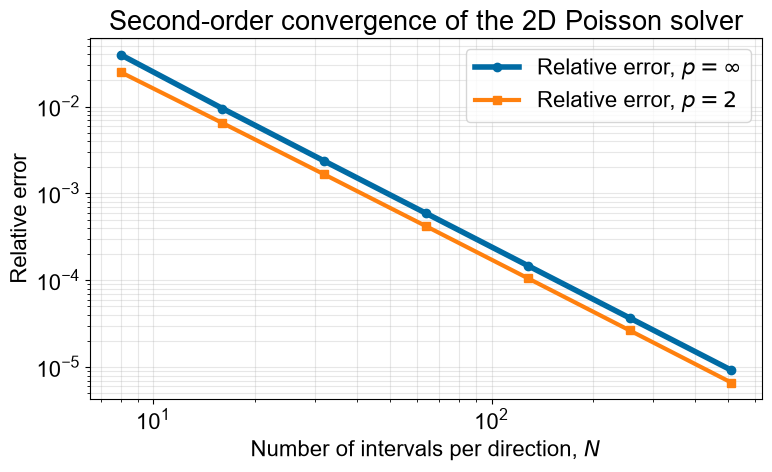

In [ ]:
# Relative-error convergence for the 2D Poisson solver.
N_values = np.array([8, 16, 32, 64, 128, 256, 512])
error_inf = np.empty(len(N_values))
error_2 = np.empty(len(N_values))

for index, N in enumerate(N_values):
    x, y, u_numerical = finite_diff_2d(
        f_2d, N, N, a, b, a, b,
        u_exact_2d
    )
    X, Y = np.meshgrid(x, y, indexing="xy")
    u_exact_values = u_exact_2d(X, Y)
    error_inf[index] = relative_error(u_numerical.ravel(), u_exact_values.ravel(), np.inf)
    error_2[index] = relative_error(u_numerical.ravel(), u_exact_values.ravel(), 2)

plt.figure(figsize=(8, 5))
plt.loglog(N_values, error_inf, "o-", label=r"Relative error, $p=\infty$", linewidth=4)
plt.loglog(N_values, error_2, "s-", label=r"Relative error, $p=2$", linewidth=3)
plt.xlabel(r"Number of intervals per direction, $N$")
plt.ylabel("Relative error")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()